<a href="https://colab.research.google.com/github/sathana495/Deep_Learning_projects/blob/main/Brain_Tumor_Detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os

os.listdir('/content/drive/MyDrive/dataset/Brain_Tumor_Datasets')

['test', 'train']

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
train_path = "/content/drive/MyDrive/dataset/Brain_Tumor_Datasets/train"
test_path = "/content/drive/MyDrive/dataset/Brain_Tumor_Datasets/test"

In [7]:
print(train_path)
print(test_path)

/content/drive/MyDrive/dataset/Brain_Tumor_Datasets/train
/content/drive/MyDrive/dataset/Brain_Tumor_Datasets/test


**Step 1:Image Preprocessing**

In [8]:
train_datagen = ImageDataGenerator( rescale=1./255,rotation_range=20,zoom_range=0.2, horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

**Load the images from the dataset**

In [9]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 7023 images belonging to 2 classes.
Found 1764 images belonging to 2 classes.


In [10]:
import matplotlib.pyplot as plt
import numpy as np

In [11]:
images, labels = next(train_data)


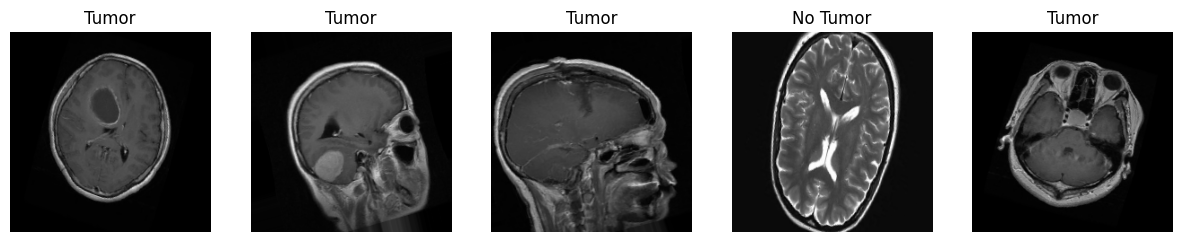

In [12]:
plt.figure(figsize=(15, 5))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i])

    if labels[i] == 1:
        plt.title("Tumor")
    else:
        plt.title("No Tumor")

    plt.axis("off")

plt.show()

In [13]:
print(train_data.class_indices)

{'no': 0, 'yes': 1}


In [14]:
print(train_data.batch_size)

32


In [15]:
print(images[0].shape)

(224, 224, 3)


In [16]:
print("Training Images:", train_data.samples)
print("Testing Images:", test_data.samples)

Training Images: 7023
Testing Images: 1764


In [17]:
import os

print("Train folders:", os.listdir(train_path))
print("Test folders:", os.listdir(test_path))

Train folders: ['no', 'yes']
Test folders: ['yes', 'no']


In [18]:
print("Train samples:", train_data.samples)
print("Test samples:", test_data.samples)

Train samples: 7023
Test samples: 1764


In [19]:
import os

print("Train YES:", len(os.listdir(train_path + "/yes")))
print("Train NO :", len(os.listdir(train_path + "/no")))

Train YES: 4143
Train NO : 2880


In [20]:
print("Test YES:", len(os.listdir(test_path + "/yes")))
print("Test NO :", len(os.listdir(test_path + "/no")))

Test YES: 1035
Test NO : 729


**create CNN model**

In [21]:
model = tf.keras.Sequential()

In [22]:
model.add(tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(224,224,3)
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.add(tf.keras.layers.MaxPooling2D(
    pool_size=(2,2)
))

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.add(tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

In [27]:
model.add(tf.keras.layers.MaxPooling2D(
    pool_size=(2,2)
))

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.add(tf.keras.layers.Flatten())

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.add(tf.keras.layers.Dense(
    units=128,
    activation='relu'
))

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,392 (91.20 MB)

 Trainable params: 23,907,392 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [36]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 1478s 7s/step - accuracy: 0.8508 - loss: 0.4013 - val_accuracy: 0.9359 - val_loss: 0.2076
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 123s 559ms/step - accuracy: 0.9272 - loss: 0.2029 - val_accuracy: 0.9388 - val_loss: 0.1838
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 125s 569ms/step - accuracy: 0.9381 - loss: 0.1767 - val_accuracy: 0.9246 - val_loss: 0.2120
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 122s 556ms/step - accuracy: 0.9432 - loss: 0.1580 - val_accuracy: 0.9467 - val_loss: 0.1391
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 122s 552ms/step - accuracy: 0.9453 - loss: 0.1464 - val_accuracy: 0.9552 - val_loss: 0.1147
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 123s 559ms/step - accuracy: 0.9452 - loss: 0.1396 - val_accuracy: 0.9422 - val_loss: 0.1636
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 126s 574ms/step - accuracy: 0.9499 - loss: 0.1310 - val_accuracy: 0.9603 - val_loss: 0.1050
Epoch 8/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 139s 561ms/step - accuracy: 0.9476 - l

In [37]:
model.save("brain_tumor_model.keras")

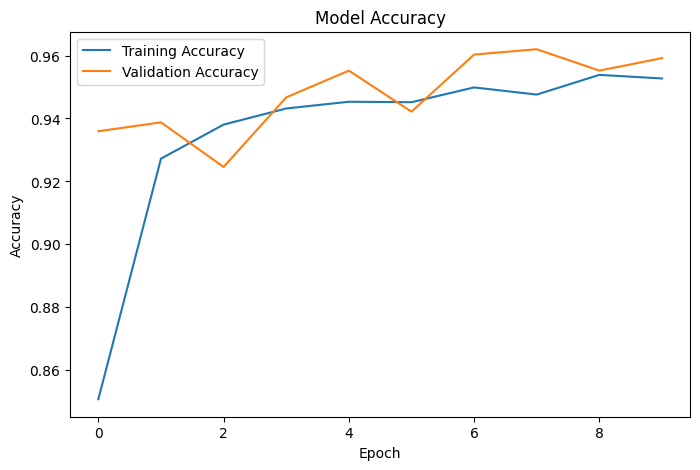

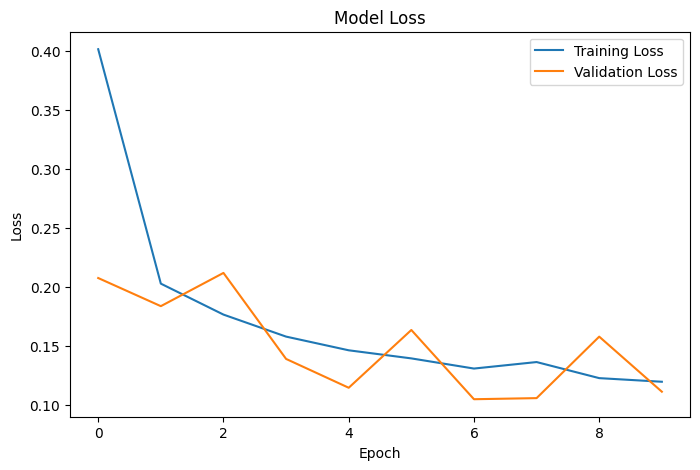

In [38]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
loss, accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.9592 - loss: 0.1114
Test Accuracy: 95.92%
Test Loss: 0.1114


In [46]:
from google.colab import files
uploaded = files.upload()

Saving no985.jpg to no985.jpg


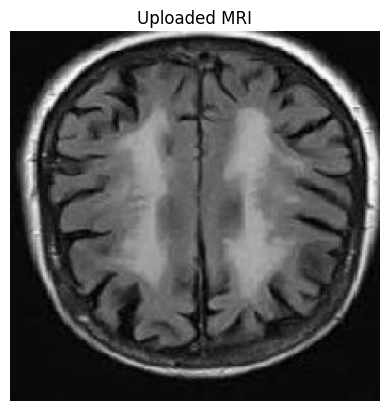

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Show image
plt.imshow(img)
plt.title("Uploaded MRI")
plt.axis("off")
plt.show()

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

In [48]:
prediction = model.predict(img_array)

tumor_probability = prediction[0][0]

print(f"Tumor Probability: {tumor_probability:.4f}")

if tumor_probability >= 0.5:
    print("🧠 Prediction: Tumor")
else:
    print("✅ Prediction: No Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Tumor Probability: 0.0710
✅ Prediction: No Tumor
